# Module 1 Topic 4 Practical — Support Vector Machines

This practical examines margin-based classification using linear, polynomial and RBF kernels. Scaling, data splitting and plotting are supplied so the active work remains focused on kernel choice, support vectors and the trade-off controlled by C.

## Official implementation guides

These optional official guides connect this topic's concepts to standard Python implementations and the practical work. They are not required for assessment.

- [Support Vector Machines user guide](https://scikit-learn.org/stable/modules/svm.html) — connect margins, kernels and hyperparameters to scikit-learn models.
- [`StandardScaler` reference](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html) — understand why feature scaling matters for distance- and margin-based models.
- [Pipeline guide](https://scikit-learn.org/stable/modules/compose.html#pipeline) — combine preprocessing and an SVM safely in one workflow.

## Learning outcomes

By the end of this practical, you should be able to:

- compare linear and nonlinear SVM kernels;
- explain why feature scaling belongs inside the pipeline;
- relate C to margin violations and support-vector count;
- select settings using validation evidence and reserve test data for final evaluation.
- implement a two-parameter validation search and refit the selected model.

### Good habits used in this notebook

- Keep preprocessing inside the pipeline to prevent leakage.
- Change one modelling choice at a time.
- Select settings with validation data, not the test set.
- Inspect boundary shape and support vectors as well as accuracy.

These habits support the topic; they are not separate programming exercises.

### If Python is new to you

- Run the notebook from top to bottom because later cells use variables created earlier.
- Begin with the short `TODO` completions, then use the completed earlier cells as patterns for the larger coding challenge.
- Read the input and expected output described above each code cell before writing code.
- Build the challenge one step at a time and run the cell after each small section.
- Ask a tutor about the first error message before changing unrelated code.
- To write an explanation, double-click the Markdown cell labelled **Write your answer**, replace the prompt, and run the cell.

The practical is designed for a two-hour session. The core student-written and adapted coding should take approximately **45–60 minutes**; interpretation and discussion are additional to that coding time.

## Setup

No external dataset download is required. The setup cell generates the reproducible teaching dataset locally, so this practical can run offline.


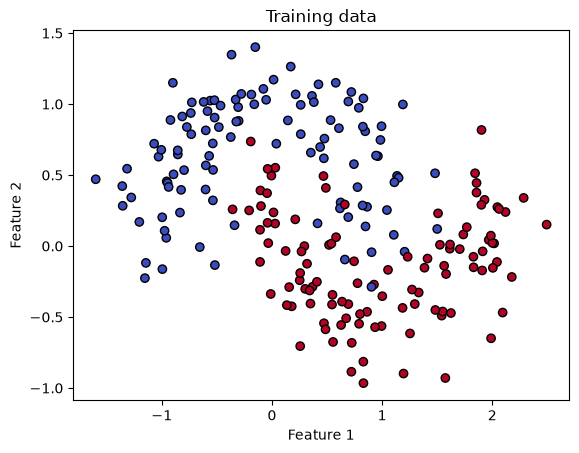

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.datasets import make_moons
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

RANDOM_STATE = 42
X, y = make_moons(n_samples=360, noise=0.24, random_state=7)
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, stratify=y_trainval, random_state=RANDOM_STATE
)
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap="coolwarm", edgecolor="k")
plt.title("Training data"); plt.xlabel("Feature 1"); plt.ylabel("Feature 2"); plt.show()

## Question 1 — Compare kernels fairly

Complete the three kernel names. `C`, scaling and data are held fixed so the kernel is the main change.

In your written answer, compare the validation accuracy and support-vector count across kernels, identify any clear underfitting, and state which kernel you would carry forward from this evidence. Explain why one validation split cannot establish universal superiority.


In [2]:
kernel_settings = {
    # TODO 1: enter 'linear'.
    "linear": {"kernel": "linear"},
    # TODO 2: enter 'poly'. Keep degree 3.
    "polynomial": {"kernel": "poly", "degree": 3},
    # TODO 3: enter 'rbf'.
    "RBF": {"kernel": "rbf", "gamma": "scale"},
}
kernel_rows = []
kernel_models = {}
for name, settings in kernel_settings.items():
    model = Pipeline([
        ("scale", StandardScaler()),
        ("svc", SVC(C=1, **settings)),
    ])
    model.fit(X_train, y_train)
    kernel_models[name] = model
    kernel_rows.append((
        name,
        accuracy_score(y_val, model.predict(X_val)),
        model.named_steps["svc"].n_support_.sum(),
    ))
kernel_results = pd.DataFrame(kernel_rows, columns=["kernel", "validation_accuracy", "support_vectors"])
display(kernel_results)

,kernel,validation_accuracy,support_vectors
0,linear,0.833333,73
1,polynomial,0.805556,73
2,RBF,0.916667,71


### Write your answer — Question 1

Compare the kernels using validation accuracy and support-vector count, identify underfitting, choose a candidate kernel, and state the limitation of this evidence.

Here, RBF shows the most validation accuracy but has the least support vectors. However, even though linear and polynomial has more support vectors, their validation accuracy is low. This is a sign of underfitting. Therefore, if I had to choose a candidate kernel, I would choose RBF. However, This result is based on one test run. If there was multiple test runs with different sets of data, there may be different result.

## Question 2 — Inspect decision boundaries

Run the supplied helper. The large outlined circles identify the training observations used as support vectors.

In your written answer, identify a boundary that underfits, describe any unnecessary complexity, explain how support vectors determine the fitted boundary, and explain why boundary shapes in regions with little data should be interpreted cautiously.


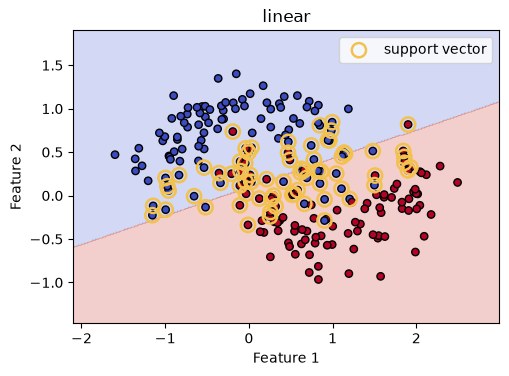

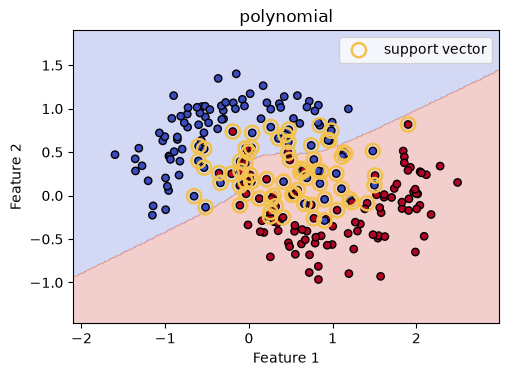

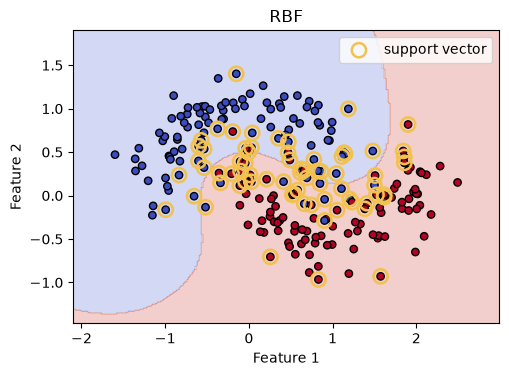

In [3]:
def plot_boundary(model, title):
    xx, yy = np.meshgrid(
        np.linspace(X[:, 0].min()-0.5, X[:, 0].max()+0.5, 240),
        np.linspace(X[:, 1].min()-0.5, X[:, 1].max()+0.5, 240),
    )
    labels = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    plt.figure(figsize=(5.5, 3.8))
    plt.contourf(xx, yy, labels, alpha=0.25, cmap="coolwarm")
    plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap="coolwarm", edgecolor="k", s=28)
    support_indices = model.named_steps["svc"].support_
    plt.scatter(
        X_train[support_indices, 0], X_train[support_indices, 1],
        facecolors="none", edgecolors="#F2C14E", linewidths=1.8,
        s=105, label="support vector"
    )
    plt.title(title); plt.xlabel("Feature 1"); plt.ylabel("Feature 2")
    plt.legend(loc="best")
    plt.show()

for name, model in kernel_models.items():
    plot_boundary(model, name)

### Write your answer — Question 2

Discuss underfitting, unnecessary boundary complexity, the role of the outlined support vectors, and uncertainty in regions with few observations.

The linear model does not punish outliers or mislabelled features which results in a linear boundary. This causes the boundary line to be unaffected by significant features, which can result in underfitting. While the polynomial does punish some violations, it is mostly like the linear and not as accurate.

The RBF, on the other hand, results in a boundary that is curved in order to fit the data better. There is no strong evidence of unnecessary complexity in the RBF boundary from these plots. Its extra curvature is supported by its better validation accuracy, although bends far away from the observed points should not be over-interpreted. The outlined observations are the support vectors. These are the training points closest to, or violating, the margin, and they are the points that determine the fitted SVM boundary. In regions with very few observations, the exact boundary shape is uncertain because there is little data there to constrain where the boundary should lie.

## Question 3 — Tune C using validation data

Complete the candidate list. Smaller `C` tolerates more violations; larger `C` penalises them more strongly.

In your written answer, report the preferred `C` from the validation results, describe how validation accuracy and support-vector count change across the candidates, and explain why `C` should not be selected using the test set.


In [4]:
# TODO 4: compare 0.1, 1 and 100.
c_candidates = [0.1,1,100]
c_rows = []
c_models = {}
for C in c_candidates:
    model = Pipeline([
        ("scale", StandardScaler()),
        ("svc", SVC(kernel="rbf", gamma="scale", C=C)),
    ])
    model.fit(X_train, y_train)
    c_models[C] = model
    c_rows.append((C, accuracy_score(y_val, model.predict(X_val)), model.named_steps["svc"].n_support_.sum()))
c_results = pd.DataFrame(c_rows, columns=["C", "validation_accuracy", "support_vectors"])
display(c_results)

,C,validation_accuracy,support_vectors
0,0.1,0.861111,120
1,1.0,0.916667,71
2,100.0,0.902778,36


### Write your answer — Question 3
Report the validation-selected `C`, describe the accuracy/support-vector pattern, and explain why the test set is not used for this choice.

C determines how strongly classification should be penalised. A small C accepts more violations resulting in a more smoother boundary line while a bigger C punishes more violation, which results in a more curvier boundary line that tries to keep as many of the same features on one side as possible. 

As C=0.1 doesn't punish violations as much, it will result in a smoother boundary line which will contain a wide margin with a lot of support vectors. This causes the boundary line to be unaffected by significant features and similar features are misclassified as well due to underfitting. This resulted in the lowest validation accuracy. 

As C=100 punishes violations as much as possible, it will result in a curvier boundary line which will contain a narrow margin with as less number of support vectors it can. This causes the boundary line to be affected by insignificant features or outliers which causes overfitting. This resulted in the second lowest accuracy.

Since having C too small or too big is bad, we have to keep C at a moderate value. That is why C=1 has the highest accuracy while having a moderate number of support vectors.

C should be selected using validation data, not the test set, because using the test set for tuning would leak information from the final evaluation into model selection and make the reported test performance optimistically biased.    

## Question 4 — Coding challenge: search C and gamma together

Real model selection often involves interacting hyperparameters. Build a two-dimensional validation search for an RBF SVM using four `C` values and three `gamma` values.

For every candidate, fit the same leakage-safe pipeline and record validation accuracy and support-vector count. Sort the results and select the highest validation accuracy, using fewer support vectors only as a tie-breaker. Do not use the test set during this search.

In your written answer, report the selected `C` and `gamma`, describe what happens at very small or large values, and explain why this finite grid and single validation split do not guarantee universally best settings.


In [5]:
# Coding challenge: search C and gamma together using validation data only.
c_grid = [0.1, 1, 10, 100]
gamma_grid = [0.1, 1, 10]
search_rows = []

# TODO 5: write the nested loops over C and gamma.
for C in c_grid:
    for gamma in gamma_grid:
        # TODO 6: create the scaling + RBF SVM pipeline.
        candidate = Pipeline([
            ("scale", StandardScaler()),
            ("svc", SVC(kernel="rbf", C=C, gamma=gamma)),
        ])
        # TODO 7: fit on training data and predict validation data.
        candidate.fit(X_train, y_train)
        validation_prediction = candidate.predict(X_val)

        # TODO 8: append a dictionary containing C, gamma, validation
        # accuracy and total support-vector count.
        search_rows.append({
            "C": C,
            "gamma": gamma,
            "validation_accuracy": accuracy_score(y_val, validation_prediction),
            "support_vectors": candidate.named_steps["svc"].n_support_.sum(),
        })

# TODO 9: create and sort a DataFrame: highest accuracy first, then
# fewer support vectors. Display every candidate.
search_results = pd.DataFrame(search_rows)
search_results = search_results.sort_values(
    ["validation_accuracy", "support_vectors"], ascending=[False, True]
).reset_index(drop=True)
display(search_results)

# TODO 10: extract the selected C and gamma from the first row.
best_c = float(search_results.loc[0, "C"])
best_gamma = float(search_results.loc[0, "gamma"])
print("Selected C:", best_c, "Selected gamma:", best_gamma)

,C,gamma,validation_accuracy,support_vectors
0,1.0,1.0,0.958333,64
1,10.0,1.0,0.930556,45
2,1.0,10.0,0.930556,123
3,0.1,10.0,0.930556,216
4,100.0,1.0,0.916667,31
5,100.0,0.1,0.916667,58
6,100.0,10.0,0.916667,99
7,10.0,10.0,0.902778,109
8,0.1,1.0,0.902778,129
9,10.0,0.1,0.861111,73


Selected C: 1.0 Selected gamma: 1.0


### Write your answer — Question 4

Report the selected `C` and `gamma`, interpret small and large settings using validation performance or support vectors, and state the limits of the search.


## Question 5 — Final unbiased evaluation

After choosing the kernel, `C` and `gamma` from validation results, refit on all training/validation data and evaluate once on the untouched test set.

In your written answer, report the fixed settings and final test accuracy. Explain why the test set is used only once and how repeatedly selecting settings from test performance would bias the evaluation.


In [ ]:
final_model = Pipeline([
    ("scale", StandardScaler()),
    # TODO 11: use the selected best_c and best_gamma.
    ("svc", SVC(kernel="rbf", C=..., gamma=...)),
])
# TODO 12: fit on all training/validation data and evaluate the test set once.
final_model.fit(..., ...)
final_test_accuracy = accuracy_score(y_test, final_model.predict(...))
print(f"Final test accuracy: {final_test_accuracy:.3f}")

### Write your answer — Question 5

Report the fixed settings and final test accuracy. Explain why the test set is evaluated once and how test-driven model selection would bias the result.


## Optional extensions

These are not required. Use them only after completing the core work:

- Use cross-validation to compare the candidate settings.
- Plot the selected model's support vectors and relate them to the margin and difficult observations.

## Summary

This practical connected the week’s ideas:

- kernels control the shape of the decision boundary;
- C controls the margin–violation trade-off;
- pipelines prevent preprocessing leakage;
- validation selects settings and the test set estimates final generalisation.
- structured validation searches expose interactions between hyperparameters.